# Lab 7 — Dimensionality Reduction and Discriminant Analysis

Today we are dealing with high-dimensional data. When you have datasets with dozens or hundreds of features, two major problems occur:
1. **The Curse of Dimensionality:** Machine learning models become slow, noisy, and prone to overfitting.
2. **Visualization:** Humans cannot visualize anything beyond 3 dimensions.

To solve this, we use **Dimensionality Reduction**. We will explore:
* **PCA (Principal Component Analysis):** An *unsupervised* technique that compresses data while preserving maximum variance.
* **LDA (Linear Discriminant Analysis):** A *supervised* technique that compresses data by maximizing the separation between known classes.
* **QDA (Quadratic Discriminant Analysis):** A non-linear extension of LDA used for powerful classification.

### 1. The Dataset
We will use the **Wine Dataset**, which contains 13 chemical measurements (features) for 3 different cultivars (classes) of wine. Our goal is to reduce these 13 dimensions down to just 2 so we can plot them on a standard graph.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# 1. Load the data
wine = load_wine()
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [5]:
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print(f"Original X shape: {X.shape}") # 13 dimensions!
print(X)


Original X shape: (178, 13)
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonfla

In [6]:
print(y.shape)
print(y)

(178,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [7]:
# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Scaling (CRITICAL STEP)
# PCA is highly sensitive to the scale of the features. We MUST use StandardScaler.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
bc = pd.read_csv("data/breast_cancer.csv")
bc.drop(columns=['id', 'Unnamed: 32'], inplace=True)
bc["diagnosis"] = bc["diagnosis"].map({'B': 0, 'M': 1})

In [9]:
bc.shape

(569, 31)

In [10]:
X_bc = bc.drop('diagnosis', axis=1)
y_bc = bc['diagnosis']

In [11]:
X_bc.shape

(569, 30)

In [12]:
y_bc.shape

(569,)

In [13]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

In [14]:
scaler_bc = StandardScaler()

X_train_scaled_bc = scaler_bc.fit_transform(X_train_bc)
X_test_scaled_bc = scaler_bc.transform(X_test_bc)

---
## 2. Principal Component Analysis (PCA)

PCA is an **unsupervised** algorithm. It looks at our 13-dimensional data and tries to find new axes (called Principal Components) that capture the maximum amount of spread (variance) in the data.

**Key Rule:** PCA does *not* look at our target labels (`y`). It doesn't know which row is Wine Class 0, 1, or 2. It only looks at the raw chemical measurements and tries to compress them mathematically.

In [16]:
from sklearn.decomposition import PCA
# Documentation: If n_components is not set then all components are stored and the sum of the ratios is equal to 1.0.

# Initialize PCA to keep all components first so we can see their importance
pca_full = PCA() #n_components=None means you are not compressing the data
pca_full.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [17]:
print(pca_full.explained_variance_)

[4.68272277 2.5174937  1.44251124 0.95025687 0.91388156 0.70002767
 0.59696802 0.31659155 0.26741076 0.25909606 0.22087117 0.14241154
 0.09544816]


In [18]:
print(pca_full.explained_variance_ratio_)

[0.35730453 0.19209164 0.11006755 0.07250719 0.06973166 0.05341402
 0.04555029 0.0241568  0.02040417 0.01976974 0.01685307 0.01086639
 0.00728295]


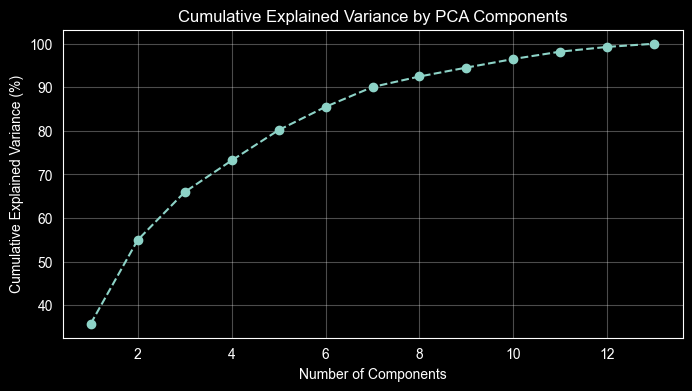

In [19]:
# Calculate how much variance each of the 13 new components explains
explained_variance = pca_full.explained_variance_ratio_ * 100

# Plotting the "Scree Plot"
plt.figure(figsize=(8, 4))
plt.plot(range(1, 14), np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.grid(alpha=0.3)
plt.show()

New X shape after PCA: (124, 2)


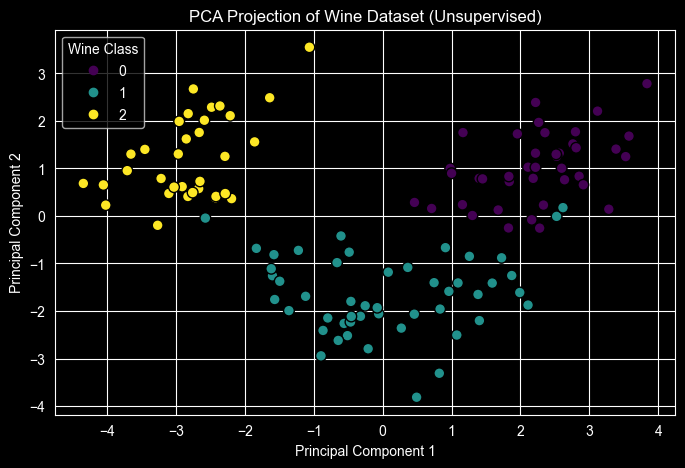

In [20]:
# Now let's compress the data down to exactly 2 dimensions for visualization
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train_scaled)

print(f"New X shape after PCA: {X_train_pca.shape}")

# Visualizing the 2D PCA projection
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=60)
plt.title('PCA Projection of Wine Dataset (Unsupervised)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Wine Class")
plt.show()

Let's look at the Breast Cancer Dataset now

In [21]:
# Now let's compress the data down to exactly 2 dimensions for visualization
pca_bc = PCA(n_components=2)
X_train_pca_bc = pca_bc.fit_transform(X_train_scaled_bc)
X_test_pca_bc = pca_bc.transform(X_test_scaled_bc)

print(f"Original training shape: {X_train_scaled.shape}")
print(f"PCA training shape: {X_train_pca.shape}")
print(f"New X shape after PCA: {X_train_pca_bc.shape}")

Original training shape: (124, 13)
PCA training shape: (124, 2)
New X shape after PCA: (455, 2)


In [22]:
X_train_pca_bc

array([[-8.75937458e-01, -2.57130887e+00],
       [-2.50512803e+00,  1.92452607e-01],
       [-1.35411680e+00,  4.17850942e-01],
       [ 4.85409144e+00,  3.01757631e+00],
       [ 2.92622452e+00, -1.86654594e+00],
       [ 1.17596996e+01, -7.57381151e+00],
       [-2.16133856e+00,  5.68874521e-01],
       [ 1.24063857e+00,  9.63396648e-01],
       [-1.00949036e+00, -1.60570865e+00],
       [ 2.48457559e+00, -3.89112344e+00],
       [ 2.04013095e+00,  3.11158973e-01],
       [ 9.19934481e+00, -5.61605803e+00],
       [-2.65050527e+00,  1.52509969e+00],
       [ 5.21715943e+00, -1.12978557e-01],
       [-3.02812325e+00, -5.63518810e-01],
       [-1.61256682e+00, -1.55366586e+00],
       [-1.40016136e+00,  1.45612103e+00],
       [-6.76258877e-01,  1.74530793e+00],
       [-3.42972911e+00, -3.87796425e-01],
       [-4.85918556e+00, -2.23108672e+00],
       [-3.50388061e+00, -5.75829885e-01],
       [-8.84852131e-01,  1.67227754e-01],
       [ 3.16687021e+00, -9.74202914e-01],
       [ 1.

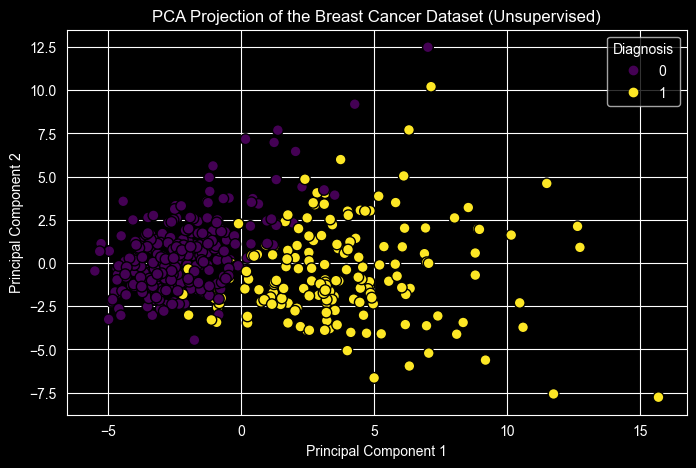

In [23]:
# Visualizing the 2D PCA projection
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_train_pca_bc[:, 0], X_train_pca_bc[:, 1], c=y_train_bc, cmap='viridis', edgecolor='k', s=60)
plt.title('PCA Projection of the Breast Cancer Dataset (Unsupervised)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Diagnosis")
plt.show()

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression()
log_reg.fit(X_train_pca_bc, y_train_bc)

y_pred = log_reg.predict(X_test_pca_bc)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_bc, y_pred):.4f}")
print(classification_report(y_test_bc, y_pred, target_names=['Benign (0)', 'Malignant (1)']))


--- Model Evaluation ---
Accuracy: 0.9474
               precision    recall  f1-score   support

   Benign (0)       0.93      0.99      0.96        72
Malignant (1)       0.97      0.88      0.93        42

     accuracy                           0.95       114
    macro avg       0.95      0.93      0.94       114
 weighted avg       0.95      0.95      0.95       114



---
## 3. Linear Discriminant Analysis (LDA)

Look at the PCA plot above. The wine classes are somewhat separated, but there is overlap. Because PCA is *unsupervised*, it didn't use our labels to help draw the map.

**LDA** is a **supervised** dimensionality reduction technique. It asks a different question: *"What new axes can I draw that will maximize the distance BETWEEN the different wine classes, while minimizing the scatter WITHIN each class?"*

Because LDA uses the target labels (`y`), it is explicitly trying to separate the groups!

StatQuest Tutorial: https://www.youtube.com/watch?v=azXCzI57Yfc

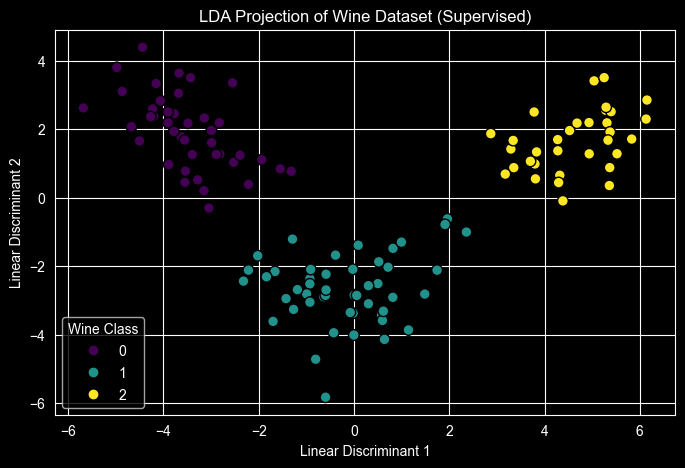

In [36]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA to reduce to 2 components
lda = LinearDiscriminantAnalysis(n_components=2)

# Notice the difference! We pass BOTH X_train and y_train to .fit()
X_train_lda = lda.fit_transform(X_train_scaled, y_train)

# Visualizing the 2D LDA projection
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=60)
plt.title('LDA Projection of Wine Dataset (Supervised)')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(*scatter.legend_elements(), title="Wine Class")
plt.show()

In [47]:
y_pred_lda = lda.predict(X_test_scaled)

print("--- LDA Classifier Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print(classification_report(y_test, y_pred_lda))

--- LDA Classifier Evaluation ---
Accuracy: 0.9815
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



If you try to run LinearDiscriminantAnalysis(n_components=2) on the Breast Cancer dataset, Python will throw an error.

### Why won't it work? (The K−1 Rule)

Unlike PCA, where you can pick any number of components you want, LDA is mathematically restricted. The maximum number of components LDA can create is K−1, where K is the number of classes in your target variable.

**The Wine Dataset:** Had 3 classes. (3−1=2). LDA could create 2 dimensions, which let us draw a beautiful 2D scatter plot.

**The Breast Cancer Dataset:** Is binary. It only has 2 classes (Malignant and Benign). (2−1=1). LDA can only squash this dataset down to exactly 1 dimension!

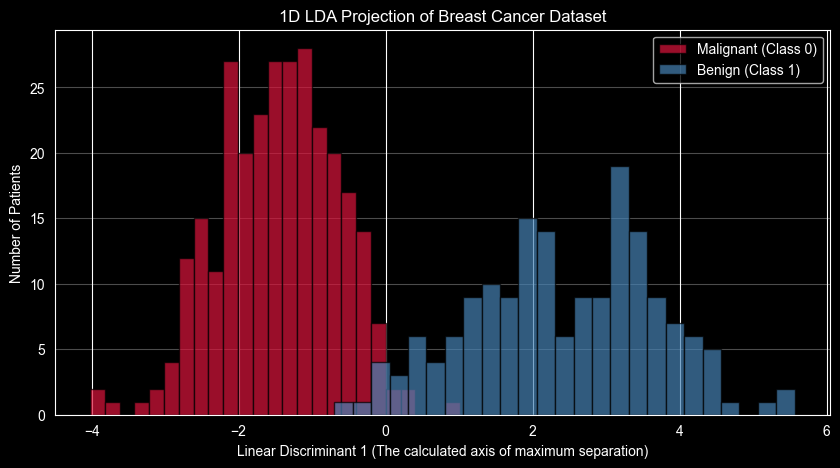

In [44]:
# 3. Run LDA
# Notice n_components=1. If you leave it blank, sklearn automatically chooses 1.
lda_bc = LinearDiscriminantAnalysis(n_components=1)
X_train_lda_bc = lda_bc.fit_transform(X_train_scaled_bc, y_train_bc)

# 4. Visualizing the 1D LDA projection using Histograms
plt.figure(figsize=(10, 5))

# Plot the distribution of Malignant tumors along the LDA axis
plt.hist(X_train_lda_bc[y_train_bc == 0], bins=25, alpha=0.7, color='crimson',
         label='Malignant (Class 0)', edgecolor='black')

# Plot the distribution of Benign tumors along the LDA axis
plt.hist(X_train_lda_bc[y_train_bc == 1], bins=25, alpha=0.7, color='steelblue',
         label='Benign (Class 1)', edgecolor='black')

plt.title('1D LDA Projection of Breast Cancer Dataset')
plt.xlabel('Linear Discriminant 1 (The calculated axis of maximum separation)')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


---
## 4. Using LDA and QDA for Classification

LDA isn't just for drawing graphs; it is a powerful generative classifier. It assumes that all classes share the same covariance matrix (meaning it assumes all clusters have roughly the same shape and orientation), drawing rigid, straight-line boundaries between them.

**Quadratic Discriminant Analysis (QDA)** relaxes this assumption. QDA allows every single class to have its own covariance matrix. This means QDA can draw curved (quadratic) decision boundaries, making it much more flexible if one class is spread out wide while another is tightly packed.

Let's race them against each other on our test set!

In [5]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

# 1. Train and Predict with LDA
lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train_scaled, y_train)
y_pred_lda = lda_clf.predict(X_test_scaled)
acc_lda = accuracy_score(y_test, y_pred_lda)

# 2. Train and Predict with QDA
qda_clf = QuadraticDiscriminantAnalysis()
qda_clf.fit(X_train_scaled, y_train)
y_pred_qda = qda_clf.predict(X_test_scaled)
acc_qda = accuracy_score(y_test, y_pred_qda)

print("--- Classifier Comparison ---")
print(f"LDA Accuracy: {acc_lda:.4f}")
print(f"QDA Accuracy: {acc_qda:.4f}\n")

print("QDA Detailed Report:")
print(classification_report(y_test, y_pred_qda))

--- Classifier Comparison ---
LDA Accuracy: 0.9815
QDA Accuracy: 1.0000

QDA Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



---
## 5. Summary and Key Takeaways

| Feature | PCA | LDA | QDA |
| :--- | :--- | :--- | :--- |
| **Type** | Unsupervised | Supervised | Supervised |
| **Goal** | Maximize overall variance | Maximize class separability | Maximize class separability |
| **Uses Labels (`y`)?** | No | Yes | Yes |
| **Decision Boundaries** | N/A | Linear (Straight lines) | Quadratic (Curves) |
| **Covariance Assumption**| N/A | All classes share the same shape | Each class has its own shape |

**Instructor Notes:**
* **Scale your data:** Always use `StandardScaler` before PCA, as it relies on variance calculations which are distorted by large numbers.
* **Dimensionality Limits:** LDA can only produce at most $K - 1$ dimensions (where $K$ is the number of classes). Since we had 3 wine classes, the maximum dimensions LDA could output was exactly 2!
* **QDA Complexity:** QDA is more flexible than LDA, but because it calculates a separate covariance matrix for every class, it requires much more data to avoid overfitting. If your dataset is very small, LDA is usually safer.